In [1]:
# 1 — Rebuild the waiting-time base from notebook 07 (same rules, same 10 terminals)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

candidates = [Path.cwd(), *Path.cwd().parents]
BASE = next((p for p in candidates if (p / "data" / "processed").exists()), None)
if BASE is None:
    raise FileNotFoundError(f"data/processed not found from {Path.cwd()} - run from inside the project folder.")
PROC = BASE / "data" / "processed"

calls = pd.read_csv(PROC / "calls_2024_2025.csv", parse_dates=["ts_arrival", "ts_berth", "ts_unberth"])
calls["terminal"] = calls["port"].str.strip() + " | " + calls["terminal_raw"].fillna("").str.strip()
calls["wait_h"] = (calls["ts_berth"] - calls["ts_arrival"]).dt.total_seconds() / 3600
calls["imo"] = pd.to_numeric(calls["imo"], errors="coerce")
calls["file_year_start"] = pd.to_datetime(calls["year"].astype(str) + "-01-01")

lc = calls[calls["navigation"] == "Longo Curso"]
w = lc[lc["ts_arrival"].between("2024-01-01", "2025-12-14 23:59")].copy()
w["arr_year"] = w["ts_arrival"].dt.year
w["month_p"] = w["ts_arrival"].dt.to_period("M")

prof = w.groupby(["terminal", "arr_year"]).agg(
    n=("call_id", "size"), teu=("teu", "mean"), p50=("wait_h", "median"),
    p90=("wait_h", lambda s: s.quantile(0.9)), below_1h=("wait_h", lambda s: (s < 1).mean())).unstack("arr_year")
ok = lambda y: (prof[("n", y)] >= 100) & (prof[("teu", y)] >= 300) & (prof[("below_1h", y)] <= 0.5) \
               & (prof[("p90", y)] / prof[("p50", y)] >= 2)
TERMINALS = prof.index[ok(2024) & ok(2025)].tolist()

uni = w[w["terminal"].isin(TERMINALS)].copy()
monthly = uni.groupby(["terminal", "month_p"]).size().unstack(fill_value=0).astype(float)
dec25 = pd.Period("2025-12", "M")
monthly[dec25] = monthly[dec25] * 31 / 14
low = monthly.lt(0.5 * monthly.drop(columns=[dec25]).median(axis=1), axis=0)
GAP_MONTHS = {(t, m) for t in low.index for m in low.columns if low.loc[t, m]}

mdf = uni[[(t, m) not in GAP_MONTHS for t, m in zip(uni["terminal"], uni["month_p"])]]
mdf = mdf[mdf["wait_h"].between(0, 14 * 24)
          & (mdf["ts_arrival"] >= mdf["file_year_start"] - pd.Timedelta(days=31))].copy()
mdf["month"] = mdf["ts_arrival"].dt.month

src = calls.dropna(subset=["ts_arrival", "ts_berth", "ts_unberth"])
src = src[(src["ts_arrival"] >= "2023-12-01") & src["wait_h"].between(0, 30 * 24)]
parts = []
for t, b in mdf.groupby("terminal"):
    s = src[src["terminal"] == t]
    t0 = b["ts_arrival"].values[:, None]
    arr, ber, unb = (s[c].values[None, :] for c in ["ts_arrival", "ts_berth", "ts_unberth"])
    parts.append(pd.DataFrame({"call_id": b["call_id"].values,
                               "q_waiting": ((arr < t0) & (ber > t0)).sum(axis=1),
                               "q_at_berth": ((ber <= t0) & (unb > t0)).sum(axis=1)}))
mdf = mdf.merge(pd.concat(parts), on="call_id", validate="1:1")

tab = pd.read_csv(PROC / "tabela_completa.csv", usecols=["IMO", "Classe_Navio", "Armador_Operador"]) \
        .rename(columns={"IMO": "imo"})
mdf = mdf.merge(tab, on="imo", how="left", validate="m:1")
mdf[["Classe_Navio", "Armador_Operador"]] = mdf[["Classe_Navio", "Armador_Operador"]].fillna("Unknown")

print(f"Terminals: {len(TERMINALS)} | calls by arrival year: {mdf['arr_year'].value_counts().sort_index().to_dict()}")
print("Median wait (h):", mdf.groupby("arr_year")["wait_h"].median().round(1).to_dict())
print("Unknown vessel share (%):",
      (100 * mdf.assign(u=mdf["Armador_Operador"] == "Unknown").groupby("arr_year")["u"].mean()).round(1).to_dict())

Terminals: 10 | calls by arrival year: {2024: 4227, 2025: 4389}
Median wait (h): {2024: 17.6, 2025: 15.2}
Unknown vessel share (%): {2024: 35.8, 2025: 11.9}


In [2]:
# 2 — Out-of-year test: train on 2024, predict every 2025 call
from sklearn.ensemble import HistGradientBoostingRegressor

for c in ["terminal", "Classe_Navio", "Armador_Operador"]:
    mdf[c + "_code"] = pd.Categorical(mdf[c]).codes
train, test = mdf[mdf["arr_year"] == 2024].copy(), mdf[mdf["arr_year"] == 2025].copy()
test["week"] = test["ts_arrival"].dt.to_period("W")

def fit_predict(feats):
    model = HistGradientBoostingRegressor(
        loss="absolute_error", max_iter=300, learning_rate=0.05, max_leaf_nodes=15,
        min_samples_leaf=40, categorical_features=[f.endswith("_code") for f in feats], random_state=42)
    model.fit(train[feats].to_numpy(float), train["wait_h"])
    return pd.Series(model.predict(test[feats].to_numpy(float)), index=test.index)

b0 = test["terminal"].map(train.groupby("terminal")["wait_h"].median())
tm = train.groupby(["terminal", "month"])["wait_h"].median()
b1 = pd.Series([tm.get((t, m), np.nan) for t, m in zip(test["terminal"], test["month"])], index=test.index).fillna(b0)

SPEC = ["terminal_code", "month", "Classe_Navio_code", "Armador_Operador_code"]
QUEUE = ["q_waiting", "q_at_berth"]
preds = {
    "B0 terminal median (2024)": b0,
    "B1 terminal x month median (2024)": b1,
    "Model: terminal + month + class + operator": fit_predict(SPEC),
    "Model: terminal + queue on arrival": fit_predict(["terminal_code"] + QUEUE),
    "Model: all of the above": fit_predict(SPEC + QUEUE),
}

rng = np.random.default_rng(42)
def ci_gain(pred, base, n_boot=1000):
    d = pd.DataFrame({"g": (test["wait_h"] - pred).abs() - (test["wait_h"] - base).abs(), "w": test["week"]})
    groups = [g["g"].to_numpy() for _, g in d.groupby("w")]
    k = len(groups)
    means = [np.concatenate([groups[j] for j in rng.integers(0, k, k)]).mean() for _ in range(n_boot)]
    return d["g"].mean(), *np.percentile(means, [2.5, 97.5])

rows = []
for name, p in preds.items():
    err = (test["wait_h"] - p).abs()
    gain, lo, hi = ci_gain(p, b1)
    rows.append({"model": name, "MAE_h": err.mean(), "median_AE_h": err.median(),
                 "median_predicted_h": p.median(), "median_actual_h": test["wait_h"].median(),
                 "gain_vs_B1_h": gain, "CI_low": lo, "CI_high": hi})
print(pd.DataFrame(rows).set_index("model").round(2).to_string())

                                            MAE_h  median_AE_h  median_predicted_h  median_actual_h  gain_vs_B1_h  CI_low  CI_high
model                                                                                                                             
B0 terminal median (2024)                   23.74        13.55               13.42            15.15         -2.45   -3.12    -1.82
B1 terminal x month median (2024)           26.20        16.00               16.27            15.15          0.00    0.00     0.00
Model: terminal + month + class + operator  24.32        14.79               16.76            15.15         -1.87   -2.46    -1.36
Model: terminal + queue on arrival          20.77        11.94               17.91            15.15         -5.43   -6.37    -4.56
Model: all of the above                     20.21        11.91               18.72            15.15         -5.99   -6.88    -5.08


In [3]:
# 3 — Gains against the right baseline, and what each variable adds
comparisons = [
    ("Model: terminal + month + class + operator", "B0 terminal median (2024)"),
    ("Model: terminal + queue on arrival", "B0 terminal median (2024)"),
    ("Model: all of the above", "B0 terminal median (2024)"),
    ("Model: all of the above", "Model: terminal + queue on arrival"),
]
rows = []
for m, b in comparisons:
    gain, lo, hi = ci_gain(preds[m], preds[b])
    rows.append({"model": m, "vs": b, "gain_h": gain, "CI_low": lo, "CI_high": hi})
print("Mean error change (negative = model is better):")
print(pd.DataFrame(rows).set_index(["model", "vs"]).round(2).to_string(), "\n")

FULL = SPEC + QUEUE
full_mae = (test["wait_h"] - preds["Model: all of the above"]).abs().mean()
drops = {"month": ["month"], "vessel class": ["Classe_Navio_code"],
         "operator": ["Armador_Operador_code"], "queue on arrival": QUEUE}
rows = []
for name, cols in drops.items():
    p = fit_predict([f for f in FULL if f not in cols])
    gain, lo, hi = ci_gain(preds["Model: all of the above"], p)
    rows.append({"removed": name, "MAE_without_h": (test["wait_h"] - p).abs().mean(),
                 "MAE_full_h": full_mae, "loss_from_removing_h": -gain, "CI_low": -hi, "CI_high": -lo})
print("Drop-one test on the full model (positive loss = the variable helps):")
print(pd.DataFrame(rows).set_index("removed").round(2).to_string())

Mean error change (negative = model is better):
                                                                               gain_h  CI_low  CI_high
model                                      vs                                                         
Model: terminal + month + class + operator B0 terminal median (2024)             0.58   -0.04     1.23
Model: terminal + queue on arrival         B0 terminal median (2024)            -2.98   -3.57    -2.42
Model: all of the above                    B0 terminal median (2024)            -3.53   -4.14    -2.93
                                           Model: terminal + queue on arrival   -0.56   -0.82    -0.31 

Drop-one test on the full model (positive loss = the variable helps):
                  MAE_without_h  MAE_full_h  loss_from_removing_h  CI_low  CI_high
removed                                                                           
month                     20.23       20.21                  0.02   -0.11     0.15
vessel class 

In [4]:
# 4 — Arrival regularity per vessel: an alternative to the contractual-window question
d = mdf.copy()
d["how"] = d["ts_arrival"].dt.dayofweek * 24 + d["ts_arrival"].dt.hour + d["ts_arrival"].dt.minute / 60
theta = 2 * np.pi * d["how"] / 168
d["c"], d["s"], d["theta"] = np.cos(theta), np.sin(theta), theta
d = d[d.groupby(["imo", "terminal"])["c"].transform("size") >= 4].copy()

g = d.groupby(["imo", "terminal"])
loo_angle = np.arctan2(g["s"].transform("sum") - d["s"], g["c"].transform("sum") - d["c"])   # slot without this call
d["off_slot_h"] = np.abs(np.angle(np.exp(1j * (d["theta"] - loo_angle)))) * 168 / (2 * np.pi)

vessel = d.groupby("imo").agg(operator=("Armador_Operador", "first"), calls=("call_id", "size"),
                              typical_off_slot_h=("off_slot_h", "median"))
print(f"Vessel x terminal pairs with >= 4 arrivals: {g.ngroups:,} | vessels: {len(vessel):,} | calls: {len(d):,}\n")
print("Vessels by typical deviation from their usual arrival slot (% of vessels):")
print((100 * pd.cut(vessel["typical_off_slot_h"], [0, 6, 12, 24, 48, 84], include_lowest=True)
       .value_counts(normalize=True).sort_index()).round(1).to_string(), "\n")

op = (vessel[vessel["operator"] != "Unknown"].groupby("operator")
      .agg(vessels=("calls", "size"), median_off_slot_h=("typical_off_slot_h", "median"),
           share_within_12h_pct=("typical_off_slot_h", lambda s: 100 * (s <= 12).mean())))
print("By operator (vessels with >= 4 arrivals at the same terminal):")
print(op[op["vessels"] >= 8].sort_values("median_off_slot_h").round(1).to_string(), "\n")

d["log_w"] = np.log1p(d["wait_h"])
d["excess"] = d["log_w"] - d.groupby(["terminal", "month_p"])["log_w"].transform("median")
d["off_band"] = pd.cut(d["off_slot_h"], [0, 6, 12, 24, 48, 84], include_lowest=True)
band = d.groupby("off_band", observed=True).agg(calls=("call_id", "size"), median_wait_h=("wait_h", "median"),
                                                 excess=("excess", "median"))
band["vs_same_terminal_month_%"] = 100 * (np.exp(band.pop("excess")) - 1)
print("Arrivals off the usual slot: do they wait longer?")
print(band.round(1).to_string())
print(f"\nSpearman (off-slot hours vs excess wait): {d['off_slot_h'].corr(d['excess'], method='spearman'):.2f}")

Vessel x terminal pairs with >= 4 arrivals: 815 | vessels: 310 | calls: 6,358

Vessels by typical deviation from their usual arrival slot (% of vessels):
typical_off_slot_h
(-0.001, 6.0]     2.9
(6.0, 12.0]      11.6
(12.0, 24.0]     25.5
(24.0, 48.0]     42.9
(48.0, 84.0]     17.1 

By operator (vessels with >= 4 arrivals at the same terminal):
             vessels  median_off_slot_h  share_within_12h_pct
operator                                                     
CMA CGM           25               19.6                  28.0
Maersk            51               20.4                  29.4
Hapag-Lloyd       22               24.0                   9.1
COSCO             13               26.8                   0.0
Múltiplos         25               29.5                  12.0
MSC               45               29.8                   6.7
HMM               10               40.4                   0.0
Evergreen          8               54.7                   0.0 

Arrivals off the usual slot: d

In [5]:
# 5 — Early or late? And does arrival regularity explain the MSC–Maersk gap?
d["signed_h"] = np.angle(np.exp(1j * (d["theta"] - loo_angle))) * 168 / (2 * np.pi)   # < 0 = earlier than usual slot
d["timing"] = pd.cut(d["signed_h"], [-48, -24, -6, 6, 24, 48],
                     labels=["early 24-48h", "early 6-24h", "on slot (+/-6h)", "late 6-24h", "late 24-48h"])
tim = d.dropna(subset=["timing"]).groupby("timing", observed=True).agg(
    calls=("call_id", "size"), median_wait_h=("wait_h", "median"), excess=("excess", "median"))
tim["vs_same_terminal_month_%"] = 100 * (np.exp(tim.pop("excess")) - 1)
print("Early vs late arrivals (within 48 h of the usual slot):")
print(tim.round(1).to_string(), "\n")

cell = d.groupby(["terminal", "month_p", "off_band"], observed=True)["log_w"]
d["excess_same_slot"] = (d["log_w"] - cell.transform("median")).where(cell.transform("size") >= 5)
pct = lambda x: 100 * (np.exp(x) - 1)
rows = []
for o, g2 in d[d["Armador_Operador"] != "Unknown"].groupby("Armador_Operador"):
    if len(g2) >= 150:
        rows.append({"operator": o, "calls": len(g2), "median_off_slot_h": g2["off_slot_h"].median(),
                     "vs_same_terminal_month_%": pct(g2["excess"].median()),
                     "vs_same_terminal_month_and_off_slot_%": pct(g2["excess_same_slot"].median())})
print("Operator wait gap, before and after comparing ships equally far from their usual slot:")
print(pd.DataFrame(rows).set_index("operator").sort_values("vs_same_terminal_month_%").round(1).to_string())

Early vs late arrivals (within 48 h of the usual slot):
                 calls  median_wait_h  vs_same_terminal_month_%
timing                                                         
early 24-48h       724           22.1                      25.1
early 6-24h       1061           14.7                       0.0
on slot (+/-6h)   1044            7.0                     -20.7
late 6-24h         993           11.3                     -13.8
late 24-48h        786           15.0                       0.0 

Operator wait gap, before and after comparing ships equally far from their usual slot:
             calls  median_off_slot_h  vs_same_terminal_month_%  vs_same_terminal_month_and_off_slot_%
operator                                                                                              
Maersk        1666               16.1                     -20.7                                  -10.7
ONE Line       193               31.3                       0.2                                   

Arrival timing by operator (% of arrivals within 48 h of the usual slot):
t                 early >6h  on slot ±6h  late >6h
Armador_Operador                                  
Maersk                 35.0         30.0      35.0
CMA CGM                38.0         27.0      34.0
ONE Line               39.0         23.0      38.0
Múltiplos              43.0         20.0      38.0
Hapag-Lloyd            37.0         18.0      45.0
COSCO                  45.0         15.0      40.0
MSC                    42.0         15.0      43.0


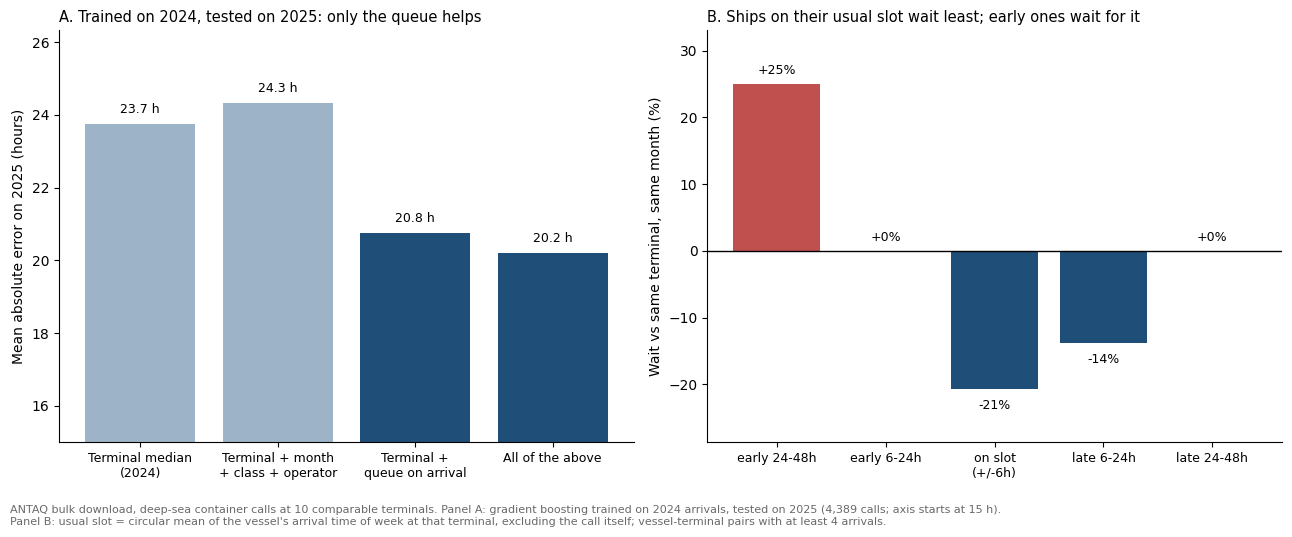

In [6]:
# 6 — Figure (fig13) and arrival timing by operator
FIG_DIR = BASE / "outputs" / "figures"

mix = (d.dropna(subset=["timing"]).query("Armador_Operador != 'Unknown'")
       .assign(t=lambda x: np.select([x["signed_h"] < -6, x["signed_h"] > 6], ["early >6h", "late >6h"], "on slot ±6h"))
       .groupby("Armador_Operador")["t"].value_counts(normalize=True).unstack().mul(100))
mix = mix[d.groupby("Armador_Operador").size().reindex(mix.index) >= 150]
print("Arrival timing by operator (% of arrivals within 48 h of the usual slot):")
print(mix[["early >6h", "on slot ±6h", "late >6h"]].sort_values("on slot ±6h", ascending=False).round(0).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

show = {"Terminal median\n(2024)": "B0 terminal median (2024)",
        "Terminal + month\n+ class + operator": "Model: terminal + month + class + operator",
        "Terminal +\nqueue on arrival": "Model: terminal + queue on arrival",
        "All of the above": "Model: all of the above"}
maes = [(test["wait_h"] - preds[k]).abs().mean() for k in show.values()]
bars = ax1.bar(range(len(show)), maes, color=["#9db4c8", "#9db4c8", "#1f4e79", "#1f4e79"])
for b_, m_ in zip(bars, maes):
    ax1.text(b_.get_x() + b_.get_width() / 2, m_ + 0.3, f"{m_:.1f} h", ha="center", fontsize=9)
ax1.set_xticks(range(len(show)), show.keys(), fontsize=9)
ax1.set_ylim(15, max(maes) + 2)
ax1.set_ylabel("Mean absolute error on 2025 (hours)")
ax1.set_title("A. Trained on 2024, tested on 2025: only the queue helps", loc="left", fontsize=10.5)

tt = tim["vs_same_terminal_month_%"]
ax2.bar(range(len(tt)), tt, color=["#c0504d" if x > 5 else ("#1f4e79" if x < -5 else "grey") for x in tt])
for i, val in enumerate(tt):
    ax2.text(i, val + (1.5 if val >= 0 else -3), f"{val:+.0f}%", ha="center", fontsize=9)
ax2.axhline(0, color="black", lw=1)
ax2.set_ylim(tt.min() - 8, tt.max() + 8)
ax2.set_xticks(range(len(tt)), [str(i).replace(" (", "\n(") for i in tt.index], fontsize=9)
ax2.set_ylabel("Wait vs same terminal, same month (%)")
ax2.set_title("B. Ships on their usual slot wait least; early ones wait for it", loc="left", fontsize=10.5)

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)

fig.text(0.01, -0.06,
         "ANTAQ bulk download, deep-sea container calls at 10 comparable terminals. Panel A: gradient boosting trained on 2024 "
         "arrivals, tested on 2025 (4,389 calls; axis starts at 15 h).\nPanel B: usual slot = circular mean of the vessel's "
         "arrival time of week at that terminal, excluding the call itself; vessel-terminal pairs with at least 4 arrivals.",
         fontsize=8, color="dimgrey")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig13_wait_prediction_v2.png", dpi=150, bbox_inches="tight")
plt.show()

## What this notebook answers

Same base as notebook 07: deep-sea container calls at 10 comparable terminals, arrivals January 2024 to 14 December 2025. Models are trained on 2024 only and tested on every 2025 call, a year they never saw.

**Can the wait at anchor be predicted from vessel class, month, terminal and carrier?** Not better than the terminal's median.

| Model (trained on 2024) | Mean error on 2025 | vs terminal median |
|---|---|---|
| Terminal median | 23.7 h | — |
| Terminal + month + class + operator | 24.3 h | +0.6 h (95% CI −0.0 to +1.2) |
| Terminal + queue on arrival | 20.8 h | −3.0 h (−3.6 to −2.4) |
| All of the above | 20.2 h | −3.5 h (−4.1 to −2.9) |

- **What ships find on arrival is what predicts their wait.** The queue cuts the error by about 3 hours per call in a year the model never saw, which confirms the result of notebook 04 out of sample.
- **Of the vessel and calendar variables, only the operator adds anything** (about 0.5 h once the queue is known). Month and class add nothing: the queue already reflects the peak season.
- **Copying last year's seasonality makes forecasts worse.** A terminal-by-month median from 2024 (26.2 h error) does worse than the plain terminal median.
- **Forecasts trained on 2024 run high for 2025** (median predicted about 18–19 h vs 15.2 h actual), because 2024 was the worse year. In practice the model would need retraining every month.

**Arrival regularity per vessel** (instead of contractual berth windows, which are not public). Each vessel's usual slot at a terminal is the circular mean of its arrival time of week, excluding the call being measured.

- **Arrival times drift a lot.** Only about 15% of vessels typically arrive within 12 hours of their usual slot at a terminal.
- **Ships arriving on their slot (±6 h) wait about 21% less** than other ships at the same terminal and month. Ships arriving more than a day early wait about 25% more, mostly waiting for their own window. Late arrivals do not wait longer than average, possibly because many "late" ships slow down on purpose until the berth is free.
- **Punctuality explains about half of the MSC–Maersk wait gap.** Maersk vessels arrive on their slot 30% of the time, MSC vessels 15%. Comparing ships equally far from their slot narrows the gap from about 51 to 28 percentage points.

## Limitations

1. **Out-of-year test over two years only;** the level shift between 2024 and 2025 shows how quickly a fixed model goes stale.
2. **The queue is only known on arrival,** so this model supports berth planning, not speed or routing decisions days ahead.
3. **The usual slot is inferred, not contractual.** Vessels that changed service or terminals that changed windows look irregular, so absolute regularity figures are likely overstated.
4. **Arrival time partly reflects berth planning** (ships slowing down when the berth is not ready), so punctuality and waiting influence each other: association, not cause.
5. **Operator, not container owner,** as in the rest of the project.